------

## Paso 4 — Análisis exploratorio

### Importar archivos y estudiar datos

In [1]:
import pandas as pd

path_01 = "/datasets/project_sql_result_01.csv"  # company_name, trips_amount (15–16 nov 2017)
path_04 = "/datasets/project_sql_result_04.csv"  # dropoff_location_name, average_trips (promedio nov 2017)

df1 = pd.read_csv(path_01)
df4 = pd.read_csv(path_04)

print("== df1 (empresas) — primeras filas ==")
print(df1.head(), "\n")
print("== df1.info() ==")
print(df1.info(), "\n")

print("== df4 (barrios) — primeras filas ==")
print(df4.head(), "\n")
print("== df4.info() ==")
print(df4.info(), "\n")

print("== Nulos ==")
print("df1:\n", df1.isna().sum(), "\n")
print("df4:\n", df4.isna().sum())


== df1 (empresas) — primeras filas ==
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299 

== df1.info() ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None 

== df4 (barrios) — primeras filas ==
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000 

== df4.info() ==
<class 'pandas.core.frame.DataFr

### Asegurar tipos correctos

In [2]:
# Normalizar tipos en df1
df1['company_name'] = df1['company_name'].astype(str)
df1['trips_amount'] = pd.to_numeric(df1['trips_amount'], errors='coerce').astype('Int64')

# Normalizar tipos en df4
df4['dropoff_location_name'] = df4['dropoff_location_name'].astype(str)
df4['average_trips'] = pd.to_numeric(df4['average_trips'], errors='coerce')

print("== Tipos corregidos ==")
print(df1.dtypes, "\n", df4.dtypes)


== Tipos corregidos ==
company_name    object
trips_amount     Int64
dtype: object 
 dropoff_location_name     object
average_trips            float64
dtype: object


### Top-10 barrios por destino de viaje

In [3]:
top10 = df4.sort_values('average_trips', ascending=False).head(10)
print("== Top 10 barrios por destino de viaje ==")
print(top10)


== Top 10 barrios por destino de viaje ==
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


### Gráficos (empresas vs viajes; top-10 barrios)

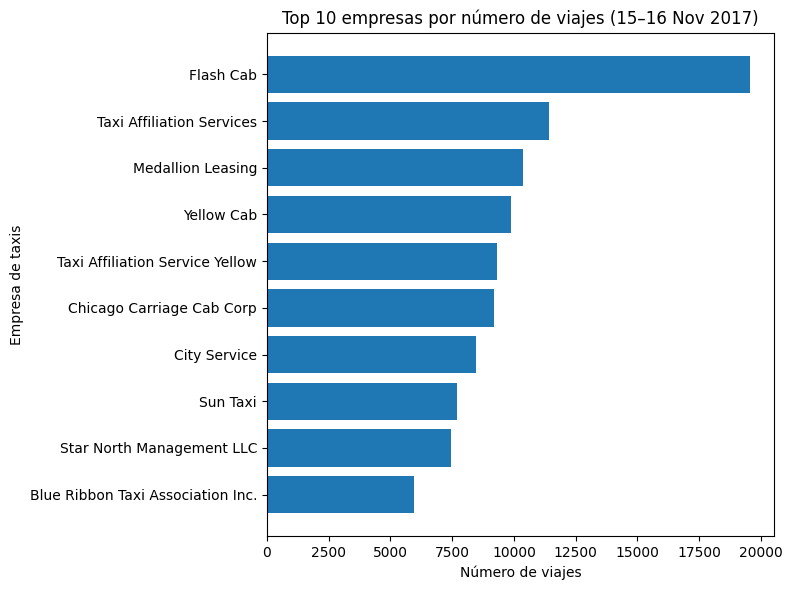

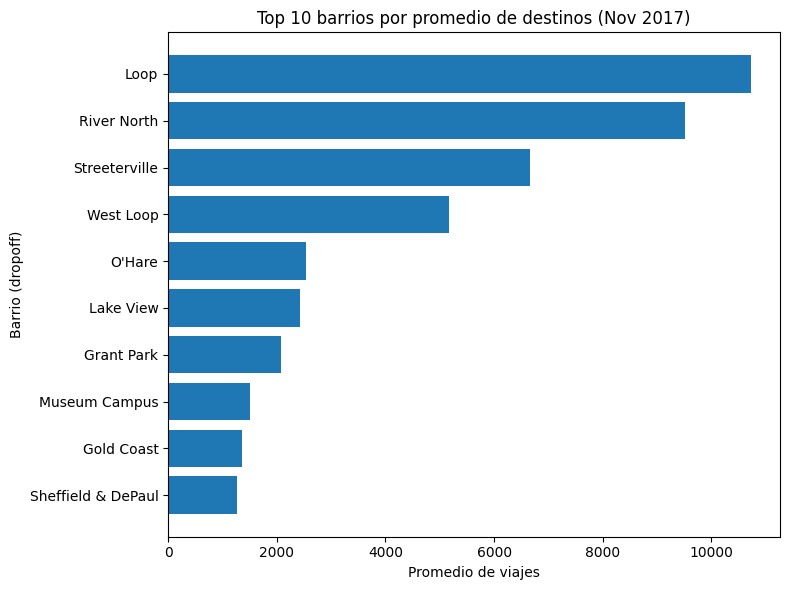

In [4]:

import matplotlib.pyplot as plt

# Ordenamos y seleccionamos el Top 10 de empresas
df1_sorted = df1.sort_values('trips_amount', ascending=False)
top10 = df1_sorted.head(10)

# Gráfico 1: Top 10 empresas por número de viajes (15–16 Nov 2017)
plt.figure(figsize=(8, 6))
plt.barh(top10['company_name'], top10['trips_amount'])
plt.title("Top 10 empresas por número de viajes (15–16 Nov 2017)")
plt.xlabel("Número de viajes")
plt.ylabel("Empresa de taxis")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Crear Top 10 de barrios por destino de viaje
top10_locations = df4.sort_values('average_trips', ascending=False).head(10)

# Gráfico 2: Top 10 barrios por promedio de finalizaciones (Nov 2017)
plt.figure(figsize=(8, 6))
plt.barh(top10_locations['dropoff_location_name'], top10_locations['average_trips'])
plt.title("Top 10 barrios por promedio de destinos (Nov 2017)")
plt.xlabel("Promedio de viajes")
plt.ylabel("Barrio (dropoff)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#### Conclusiones:

Gráfico 1, Viajes por empresa: La empresa Flash Cab lidera en cuanto a cantidad de viajes por poco menos del doble con respecto al competidor más cercano, Taxi Affiliation Services, quien supero por poco en este rubro a Medallion Leasing. Unicamente el Top 4 superan los 10,000 viajes, posteriormente decrece la cantidad de viajes gradualmente.

Gráfico 2, Top 10 de Barrios por promedio de destinos: Los barrios Loop y River North concentran la mayor cantidad de destinos de viajes, en un punto medio se encuentran Streeterville y West Loop y el resto de destinos registra una frecuencia mucho menor como destino de viajes.

## Paso 5 — Prueba de Hipótesis

### Importar y preparar datos

In [5]:
import pandas as pd

path_07 = "/datasets/project_sql_result_07.csv"
df7 = pd.read_csv(path_07)

# Convertir tipos
df7['start_ts'] = pd.to_datetime(df7['start_ts'], errors='coerce')
df7['duration_seconds'] = pd.to_numeric(df7['duration_seconds'], errors='coerce')

# Eliminar filas sin datos válidos
df7 = df7.dropna(subset=['weather_conditions', 'duration_seconds'])

df7.head()


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


### Separar los grupos Good vs Bad

In [6]:
good = df7.loc[df7['weather_conditions'] == 'Good', 'duration_seconds']
bad = df7.loc[df7['weather_conditions'] == 'Bad',  'duration_seconds']


### Formulación de la hipótesis

H0 (nula): μ_good = μ_bad
- La duración promedio no cambia con lluvia

H1 (alternativa): μ_good ≠ μ_bad
- La duración promedio sí cambia

Nivel de significancia: α = 0.05

### Prueba estadística

In [7]:
from scipy.stats import ttest_ind

alpha = 0.05

stat, pval = ttest_ind(bad, good, equal_var=False)
print("t =", stat, "p =", pval)

if pval < alpha:
    print("Se rechaza H0 → La duración promedio CAMBIA en sábados lluviosos.")
else:
    print("No se rechaza H0 → No hay evidencia de que la duración cambie con la lluvia.")


t = 7.186034288068629 p = 6.738994326108734e-12
Se rechaza H0 → La duración promedio CAMBIA en sábados lluviosos.


Se realizó una prueba estadística para evaluar si las condiciones climáticas (lluvia/tormenta) afectan la duración de los viajes realizados los sábados desde el barrio Loop hacia el Aeropuerto Internacional O’Hare.

Se formularon las siguientes hipótesis:

H0 (nula): La duración promedio de los viajes en sábados es igual en condiciones de clima “Good” (sin lluvia) y “Bad” (lluvia o tormenta).

H1 (alternativa): La duración promedio de los viajes difiere entre condiciones “Good” y “Bad”.

Para comparar las medias entre los grupos se utilizó la prueba t de Welch, debido a que los tamaños de muestra y las varianzas entre ambos grupos pueden ser diferentes. Se estableció un nivel de significancia de α = 0.05.

El resultado de la prueba fue:
t = 7.19, p ≈ 6.7 × 10⁻¹², lo cual es significativamente menor que el nivel de significancia establecido.

#### Conclusión: 

Se rechaza la hipótesis nula, lo que indica que la duración promedio de los viajes sí cambia durante sábados lluviosos. En términos prácticos, el clima adverso se asocia con viajes más largos, lo que sugiere condiciones de tráfico más lentas o mayores demoras durante el servicio.